# Customer Churn Prediction — Phase 2: EDA & Visualizations

**Goal of this notebook:**  
Understand *who* is churning and *why* — before touching a single ML algorithm.  
Every chart here is a hypothesis that the model will later confirm or reject with math.

**Charts we will build:**
1. Target variable distribution (class imbalance)
2. Churn by demographic features (SeniorCitizen, Partner, Dependents, gender)
3. Churn by service features (Contract, InternetService, PaymentMethod, OnlineSecurity)
4. Numerical distributions — KDE plots (tenure, MonthlyCharges, TotalCharges)
5. Correlation heatmap

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# ── Consistent color palette across ALL charts ───────────────────────────────
# Blue = No Churn (retained), Red = Yes Churn (lost customer)
# WHY consistent colors? So a recruiter reading your README instantly
# maps red = danger zone without re-reading legends.
COLORS = {
    'no_churn'  : '#2C6E91',   # blue
    'churn'     : '#E53935',   # red
    'neutral'   : '#90A4AE',   # grey
    'bg'        : '#F7F9FC',   # light background
}
PALETTE = [COLORS['no_churn'], COLORS['churn']]

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor' : COLORS['bg'],
    'axes.facecolor'   : COLORS['bg'],
    'axes.titleweight' : 'bold',
    'axes.titlesize'   : 13,
})

CHARTS_DIR = '../docs/charts/'

df = pd.read_csv('../data/processed/telco_churn_clean.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 7,043 rows × 21 columns


---
## Chart 1 — Target Variable Distribution
**Business question:** How severe is the class imbalance?  
A naive model that always predicts "No Churn" would be 73% accurate — and completely worthless.  
This chart establishes *why* we need SMOTE later.

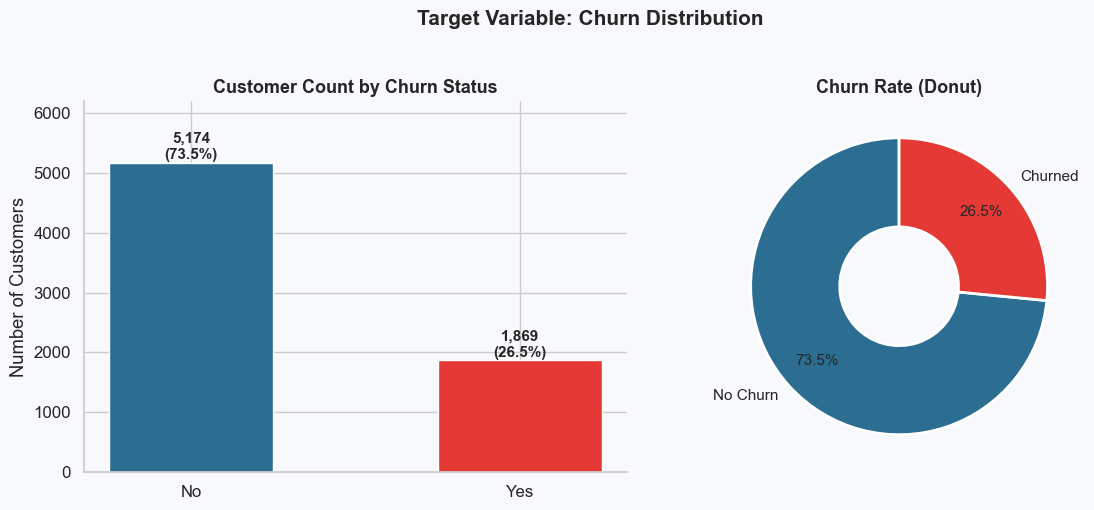


Key insight: 26.5% churn rate means ~1 in 4 customers is leaving.
A model predicting "No" every time = 73.5% accuracy but 0% useful.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: Churn Distribution', fontsize=15, fontweight='bold', y=1.02)

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=PALETTE, edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 60,
                 f'{count:,}\n({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Customer Count by Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=['No Churn', 'Churned'],
    colors=PALETTE,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    pctdistance=0.75,
    textprops={'fontsize': 11}
)
axes[1].set_title('Churn Rate (Donut)')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKey insight: 26.5% churn rate means ~1 in 4 customers is leaving.')
print('A model predicting "No" every time = 73.5% accuracy but 0% useful.')

---
## Chart 2 — Churn by Demographic Features
**Business question:** Are senior citizens, customers without partners, or those without dependents more likely to churn?  
This tells the retention team *who* to target.

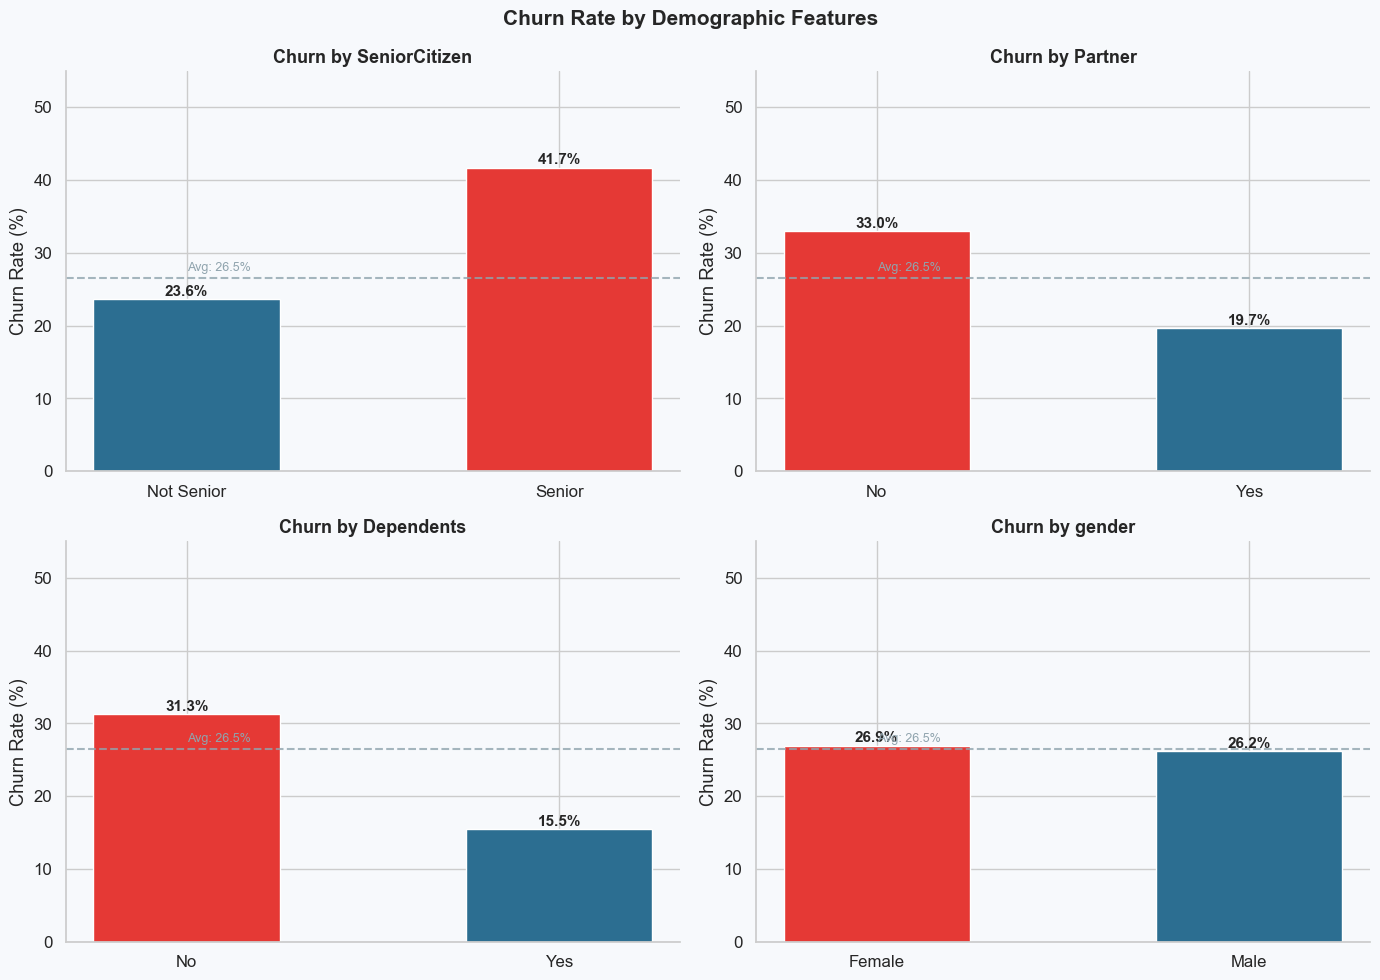


SeniorCitizen:
SeniorCitizen  ChurnRate
   Not Senior  23.606168
       Senior  41.681261

Partner:
Partner  ChurnRate
     No  32.957979
    Yes  19.664903

Dependents:
Dependents  ChurnRate
        No  31.279140
       Yes  15.450237

gender:
gender  ChurnRate
Female  26.920872
  Male  26.160338


In [3]:
# Helper: calculates churn rate per category
def churn_rate_by(col):
    return df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index(name='ChurnRate')

demographic_cols = ['SeniorCitizen', 'Partner', 'Dependents', 'gender']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Demographic Features', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(demographic_cols):
    data = churn_rate_by(col)
    # Map SeniorCitizen 0/1 to readable labels
    if col == 'SeniorCitizen':
        data[col] = data[col].map({0: 'Not Senior', 1: 'Senior'})

    bar_colors = [COLORS['churn'] if r > 26.5 else COLORS['no_churn']
                  for r in data['ChurnRate']]

    bars = axes[i].bar(data[col], data['ChurnRate'],
                       color=bar_colors, edgecolor='white', width=0.5)
    # Add rate labels on bars
    for bar, rate in zip(bars, data['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{rate:.1f}%',
                     ha='center', fontweight='bold', fontsize=11)

    # Baseline churn rate reference line
    axes[i].axhline(y=26.5, color=COLORS['neutral'], linestyle='--',
                    linewidth=1.5, alpha=0.8)
    axes[i].text(0, 27.5, 'Avg: 26.5%', color=COLORS['neutral'], fontsize=9)
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 55)
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}02_churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual numbers
for col in demographic_cols:
    data = churn_rate_by(col)
    if col == 'SeniorCitizen':
        data[col] = data[col].map({0: 'Not Senior', 1: 'Senior'})
    print(f'\n{col}:')
    print(data.to_string(index=False))

---
## Chart 3 — Churn by Service & Account Features
**Business question:** Which services are churn accelerators?  
Month-to-month contracts, Fiber Optic, and Electronic Check are the usual suspects —  
this chart will confirm that with real rates.

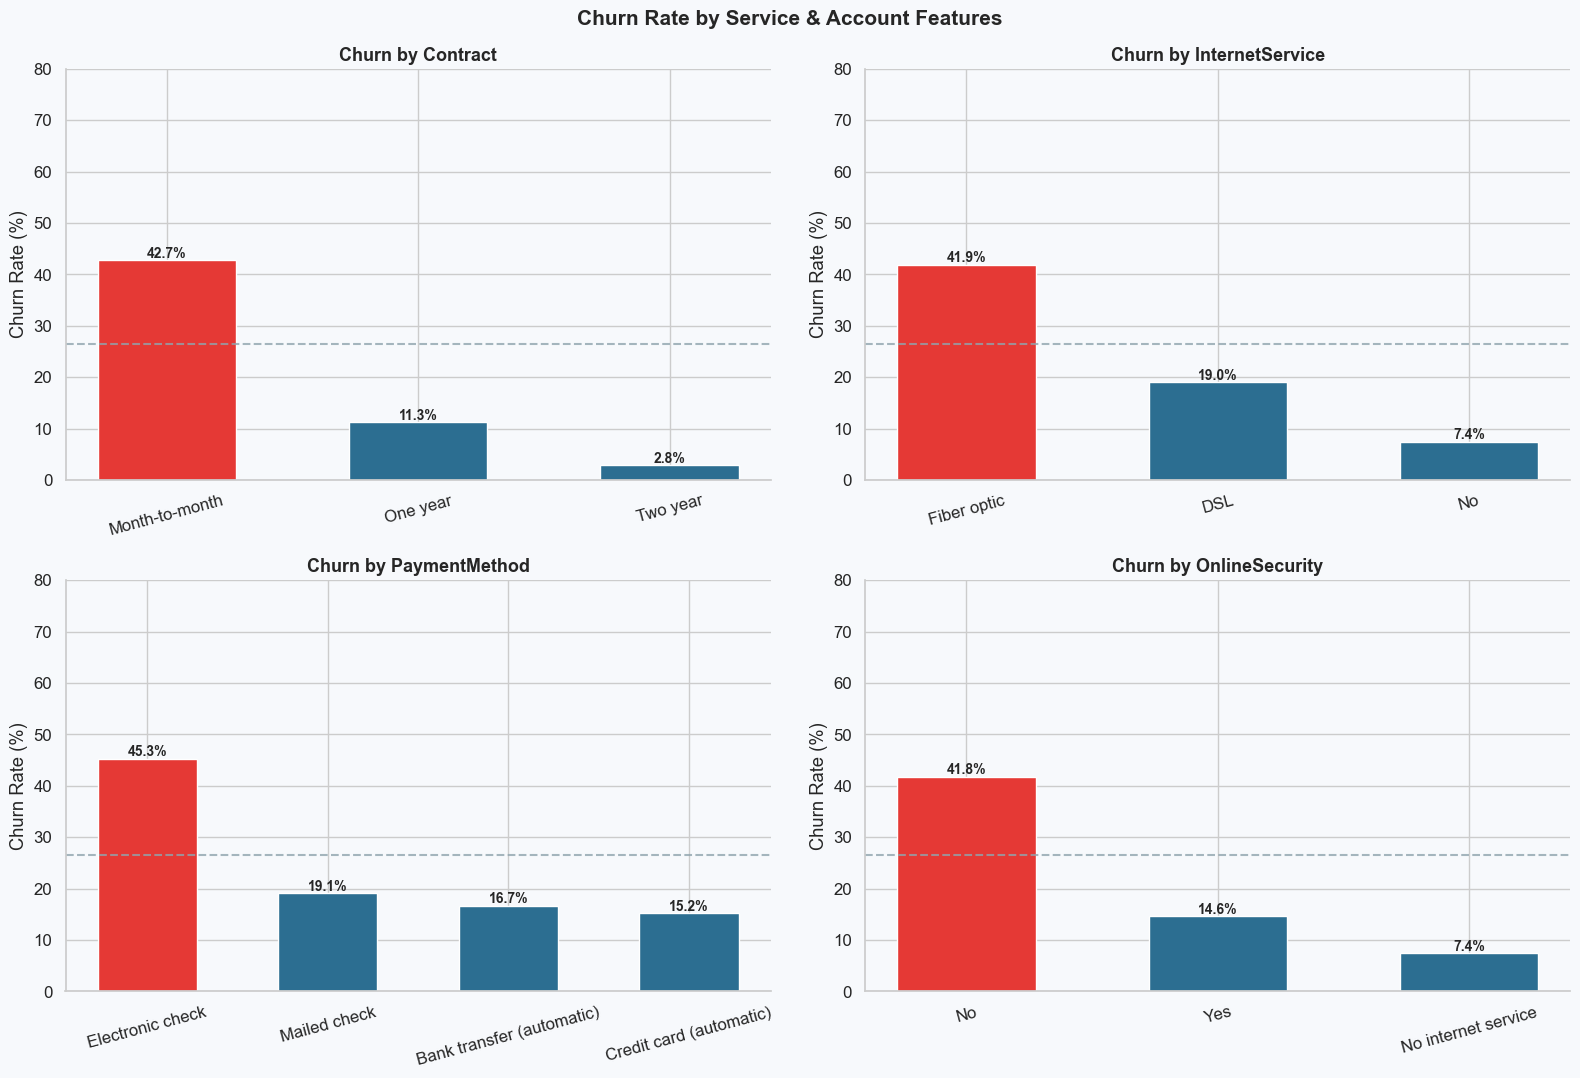


Contract:
      Contract  ChurnRate
Month-to-month  42.709677
      One year  11.269518
      Two year   2.831858

InternetService:
InternetService  ChurnRate
    Fiber optic  41.892765
            DSL  18.959108
             No   7.404980

PaymentMethod:
            PaymentMethod  ChurnRate
         Electronic check  45.285412
             Mailed check  19.106700
Bank transfer (automatic)  16.709845
  Credit card (automatic)  15.243101

OnlineSecurity:
     OnlineSecurity  ChurnRate
                 No  41.766724
                Yes  14.611194
No internet service   7.404980


In [4]:
service_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Churn Rate by Service & Account Features', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(service_cols):
    data = churn_rate_by(col).sort_values('ChurnRate', ascending=False)
    bar_colors = [COLORS['churn'] if r > 26.5 else COLORS['no_churn']
                  for r in data['ChurnRate']]

    bars = axes[i].bar(data[col], data['ChurnRate'],
                       color=bar_colors, edgecolor='white', width=0.55)
    for bar, rate in zip(bars, data['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.5,
                     f'{rate:.1f}%',
                     ha='center', fontweight='bold', fontsize=10)

    axes[i].axhline(y=26.5, color=COLORS['neutral'], linestyle='--',
                    linewidth=1.5, alpha=0.8)
    axes[i].set_title(f'Churn by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 80)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}03_churn_by_services.png', dpi=150, bbox_inches='tight')
plt.show()

for col in service_cols:
    data = churn_rate_by(col).sort_values('ChurnRate', ascending=False)
    print(f'\n{col}:')
    print(data.to_string(index=False))

---
## Chart 4 — KDE Plots: Numerical Features by Churn

**What is a KDE plot?**  
KDE (Kernel Density Estimate) is a smoothed histogram. Instead of discrete bars,  
it shows the *probability density* of values — useful for comparing two groups.  

**Business question:** Do churners have shorter tenure and higher monthly charges?  
If yes → they sign up, find the price too high, and leave quickly.

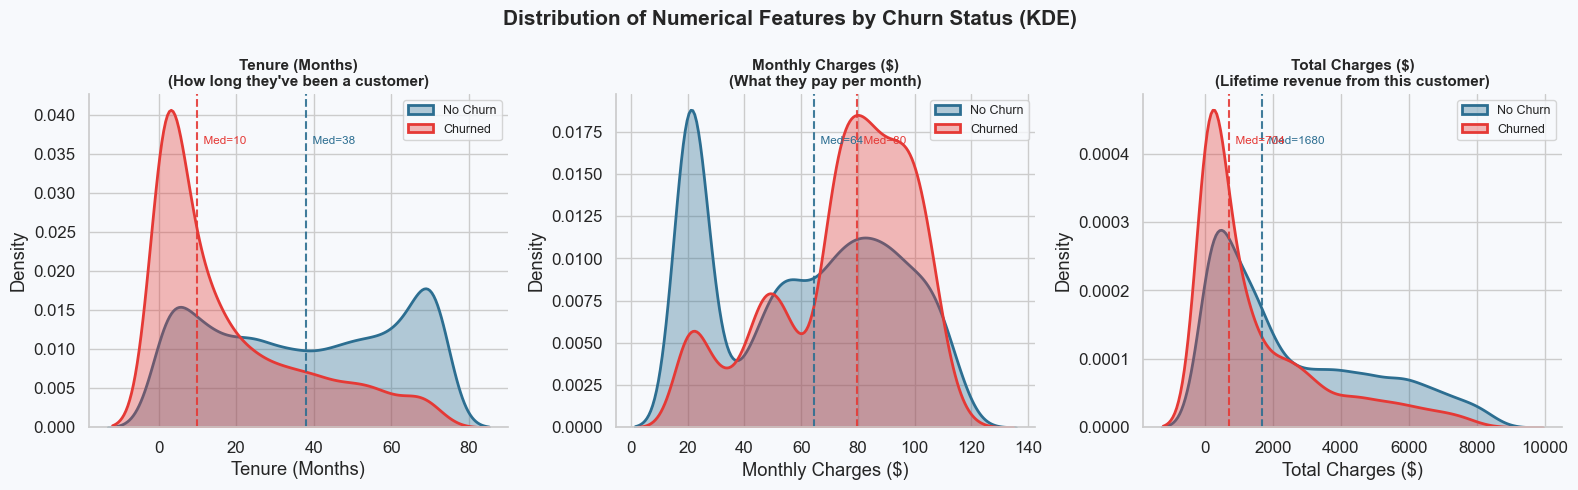

Median values by Churn group:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0            64.4        1679.5
Yes      10.0            79.6         703.6


In [5]:
numerical_cols = [
    ('tenure',         'Tenure (Months)',          'How long they\'ve been a customer'),
    ('MonthlyCharges', 'Monthly Charges ($)',       'What they pay per month'),
    ('TotalCharges',   'Total Charges ($)',         'Lifetime revenue from this customer'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Numerical Features by Churn Status (KDE)', fontsize=15, fontweight='bold')

for ax, (col, label, subtitle) in zip(axes, numerical_cols):
    for churn_val, color, name in [
        ('No',  COLORS['no_churn'], 'No Churn'),
        ('Yes', COLORS['churn'],    'Churned')
    ]:
        subset = df[df['Churn'] == churn_val][col]
        sns.kdeplot(subset, ax=ax, color=color, fill=True,
                    alpha=0.35, linewidth=2, label=name)

    # Vertical lines at group medians — makes the shift easy to see
    for churn_val, color in [('No', COLORS['no_churn']), ('Yes', COLORS['churn'])]:
        median = df[df['Churn'] == churn_val][col].median()
        ax.axvline(median, color=color, linestyle='--', linewidth=1.5, alpha=0.9)
        ax.text(median, ax.get_ylim()[1] * 0.85,
                f'  Med={median:.0f}', color=color, fontsize=8.5)

    ax.set_title(f'{label}\n({subtitle})', fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}04_kde_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

# Print median comparison table
print('Median values by Churn group:')
print(df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].median().round(1))

---
## Chart 5 — Churn Rate Heatmap by Contract × Internet Service
**Business question:** Is the worst combination Month-to-Month + Fiber Optic?  
This cross-tab reveals *compound* risk factors — useful for targeted retention campaigns.

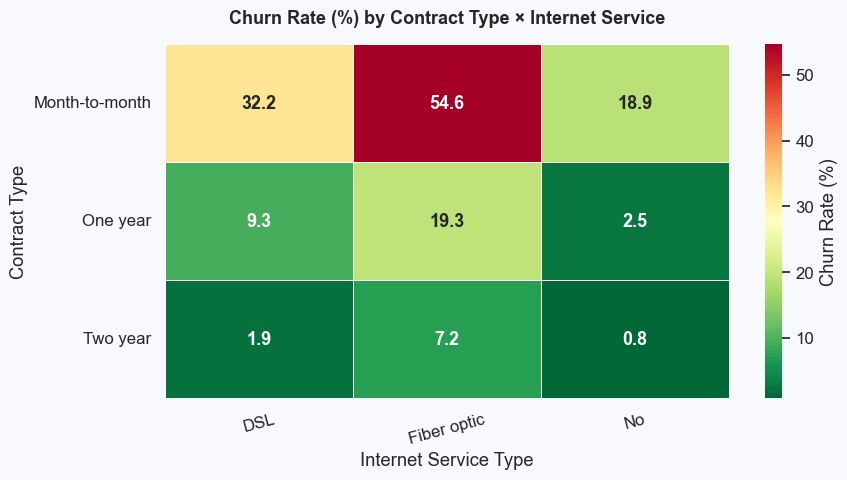

Churn rates (%) by Contract × Internet Service:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


In [6]:
# Build pivot: rows = Contract, columns = InternetService, values = churn rate
pivot = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: round((x == 'Yes').sum() / len(x) * 100, 1)
).unstack()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',           # Red = high churn, Green = low churn
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Churn Rate (%)'},
    ax=ax
)
ax.set_title('Churn Rate (%) by Contract Type × Internet Service', pad=15)
ax.set_xlabel('Internet Service Type')
ax.set_ylabel('Contract Type')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}05_churn_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Churn rates (%) by Contract × Internet Service:')
print(pivot)

---
## Chart 6 — Correlation Heatmap (Numeric Features)
**Why this matters for ML:**  
High correlation between two input features (multicollinearity) can confuse linear models.  
Knowing that `tenure` and `TotalCharges` are highly correlated (~0.83) tells us that  
`TotalCharges` is largely redundant — the model will learn this too.

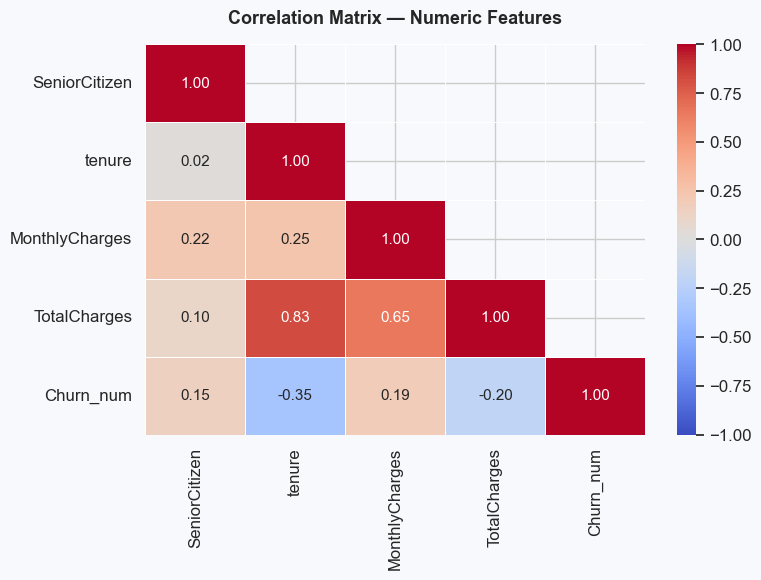

Correlation with Churn (sorted):
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_num, dtype: float64


In [7]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']
corr_matrix  = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11},
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features', pad=15)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with Churn (sorted):')
print(corr_matrix['Churn_num'].drop('Churn_num').sort_values(ascending=False))

---
## EDA Summary — Key Findings
Run this cell to get a data-backed summary for your README.

In [8]:
print('=' * 60)
print(' EDA KEY FINDINGS')
print('=' * 60)

# Churn rate
churn_rate = (df['Churn'] == 'Yes').mean() * 100
print(f'\n Overall churn rate         : {churn_rate:.1f}%')

# Senior citizens
sr_churn = df[df['SeniorCitizen']==1]['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f' Senior citizen churn rate  : {sr_churn:.1f}%')

# Month-to-month contracts
mtm = df[df['Contract']=='Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f' Month-to-month churn rate  : {mtm:.1f}%')

# Two year contracts
twyr = df[df['Contract']=='Two year']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f' Two-year contract churn    : {twyr:.1f}%')

# Fiber optic
fiber = df[df['InternetService']=='Fiber optic']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f' Fiber optic churn rate     : {fiber:.1f}%')

# Electronic check
echeck = df[df['PaymentMethod']=='Electronic check']['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f' Electronic check churn     : {echeck:.1f}%')

# Median tenure
med_t_yes = df[df['Churn']=='Yes']['tenure'].median()
med_t_no  = df[df['Churn']=='No']['tenure'].median()
print(f'\n Median tenure (churned)    : {med_t_yes:.0f} months')
print(f' Median tenure (retained)   : {med_t_no:.0f} months')

# Median monthly charges
med_m_yes = df[df['Churn']=='Yes']['MonthlyCharges'].median()
med_m_no  = df[df['Churn']=='No']['MonthlyCharges'].median()
print(f'\n Median monthly charge (churned)  : ${med_m_yes:.2f}')
print(f' Median monthly charge (retained) : ${med_m_no:.2f}')

print('\n' + '=' * 60)
print(' Phase 2 Complete. Proceed to 03_preprocessing.ipynb')
print('=' * 60)

 EDA KEY FINDINGS

 Overall churn rate         : 26.5%
 Senior citizen churn rate  : 41.7%
 Month-to-month churn rate  : 42.7%
 Two-year contract churn    : 2.8%
 Fiber optic churn rate     : 41.9%
 Electronic check churn     : 45.3%

 Median tenure (churned)    : 10 months
 Median tenure (retained)   : 38 months

 Median monthly charge (churned)  : $79.65
 Median monthly charge (retained) : $64.43

 Phase 2 Complete. Proceed to 03_preprocessing.ipynb
